In [1]:
import pandas as pd 
data = pd.read_csv("/home/ego4d/data/v2/video_540ss_splits/test_ego4d.csv")
data.head(1)

,path,num_frames,fps,duration_sec,source
0,/home/ego4d/data/v2/video_540ss_splits/6fd90f8...,5376,30.0,179.2,ego4d


In [2]:
from models.rvm_cls import RecurrentWorldModelCLS
from sklearn.decomposition import PCA

import torch
import yaml
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F
from icecream import ic
import os

In [3]:
with open("/home/rvm/configs/train_cls.yaml", "r") as f:
    config = yaml.safe_load(f)
model = RecurrentWorldModelCLS(**config.get("model", {}))

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-with-registers-large


Loading weights: 100%|██████████| 440/440 [00:00<00:00, 1721.12it/s]


In [4]:
path = '/home/rvm/checkpoints/checkpoints_rwm_cls/exp_1788255619.2001717/model_epoch3_step2700.pth'
checkpoint = torch.load(path, map_location='cpu')
print(checkpoint.keys())
model.load_state_dict(checkpoint['model'])


dict_keys(['model', 'optimizer', 'scheduler', 'epoch', 'global_step', 'config', 'local_step'])


<All keys matched successfully>

In [5]:
dir = '/home/rvm/src/helicop'
fps = 30
file_names = [os.path.join(dir, f) for f in os.listdir(dir) if f.endswith("jpg")]
# file_names
frames = []
for f in file_names:
    frame = cv2.imread(f)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (252, 252))
    frame = frame / 255.0
    frames.append(frame)

print(len(frames))
stride = 5
frames = frames[::stride]
print(len(frames))

# raw frame indices these strided samples correspond to in the original video
all_indices = np.arange(0, len(frames) * stride, stride)

708
142


In [23]:

sampled_fps = 30 / stride

device = "cpu"
model = model.to(device)
model.eval()

Base = 30       # starting position in (strided) frames
C = 15           # number of context frames
S = 5            # number of future frames to predict

context_frames = np.stack(frames[Base : Base + C])
context = torch.tensor(context_frames, dtype=torch.float32)                 # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, C, 3, H, W)

target_frames = np.stack(frames[Base + C : Base + C + S])
targets = torch.tensor(target_frames, dtype=torch.float32)                  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, S, 3, H, W)

frame_period = 1.0 / sampled_fps
context_times = (torch.arange(C, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)         # (1, C), seconds
target_times = (torch.arange(C, C + S, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)   # (1, S), seconds

# gaps[i] = target_times[i] - target_times[i-1] (or - context_times[-1] for i=0);
# consecutive sampled frames are frame_period seconds apart, so every gap is frame_period
gaps = torch.full((S,), frame_period, dtype=torch.float32, device=device)   # (S,), seconds


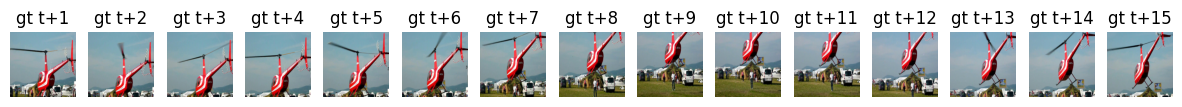

In [24]:
gt = context_frames
fig, axes = plt.subplots(1, C, figsize=(3 * S, 6))
for s in range(C):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


In [ ]:

sampled_fps = 30 / stride

device = "cuda"
model = model.to(device)
model.eval()

Base = 15       # starting position in (strided) frames
C = 15           # number of context frames
S = 5            # number of future frames to predict

context_frames = np.stack(frames[Base : Base + C])
context = torch.tensor(context_frames, dtype=torch.float32)                 # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, C, 3, H, W)

target_frames = np.stack(frames[Base + C : Base + C + S])
targets = torch.tensor(target_frames, dtype=torch.float32)                  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, S, 3, H, W)

frame_period = 1.0 / sampled_fps
context_times = (torch.arange(C, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)         # (1, C), seconds
target_times = (torch.arange(C, C + S, dtype=torch.float32) * frame_period).unsqueeze(0).to(device)   # (1, S), seconds

# gaps[i] = target_times[i] - target_times[i-1] (or - context_times[-1] for i=0);
# consecutive sampled frames are frame_period seconds apart, so every gap is frame_period
gaps = torch.full((S,), frame_period, dtype=torch.float32, device=device)   # (S,), seconds


# out = model.rollout(context=context, targets=targets, context_times=context_times, target_times=target_times)
# preds, target_feat, context_memory, context_feat, state = out["pred"], out["target_feat"], out["context_memory"], out["context_feat"], out["state"]


In [ ]:
feats = F.normalize(context_feat, dim=-1)                  # (B, C, D)
sim = torch.einsum("bcd,bed->bce", feats, feats)            # (B, C, C) pairwise cosine similarity b-etween all context frames

C = sim.shape[-1]
mask = ~torch.eye(C, dtype=torch.bool, device=sim.device)   # exclude self-similarity (diagonal is always 1)
avg_sim = sim[:, mask].mean()

print(f"context_feat pairwise cosine similarity: avg = {avg_sim.item():.4f}")


context_feat pairwise cosine similarity: avg = 0.9718


In [33]:
with torch.no_grad():
    out = model.teacher_forcing_rollout_repr(
        context=context,              # (B, C, 3, H, W)
        targets=targets,              # (B, S, 3, H, W) ground-truth future frames
        context_times=context_times,  # (B, C), seconds
        target_times=target_times,    # (B, S), seconds
    )

preds = out["pred"]                     # (B, S, D) -- predicted CLS embedding per target step
target_feat = out["target_feat"]        # (B, S, D) -- true encoded target CLS embeddings
context_memory = out["context_memory"]  # (B, C+S, D) -- core states, context + teacher-forced steps
context_feat = out["context_feat"]      # (B, C, D) -- raw encoder features for the context frames
state = out["state"]                       # (B, D) -- final GRU state

loss = F.smooth_l1_loss(preds, target_feat, beta=0.1)


In [34]:

def print_closest(gt, pred, target_indices):
    """
    gt:  (B, T_gt, D)   -- context + target features
    pred: (B, T_pred, D)
    target_indices:     -- GT index for each prediction, e.g. [C, C+1, ..., C+S-1]
    """

    gt = F.normalize(gt, dim=-1)
    pred = F.normalize(pred, dim=-1)

    # (B, T_pred, T_gt)
    sim = torch.einsum("bsd,btd->bst", pred, gt)

    # Closest GT frame for each prediction
    closest_sim, closest_idx = sim.max(dim=-1)

    target_indices = torch.as_tensor(
        target_indices,
        device=pred.device
    ).view(1, -1).expand(pred.shape[0], -1)

    # Similarity to the actual GT frame
    gt_sim = sim.gather(2, target_indices.unsqueeze(-1)).squeeze(-1)

    for b in range(pred.shape[0]):
        print(f"\nBatch {b}")
        for s in range(pred.shape[1]):
            gt_idx = target_indices[b, s].item()

            print(
                f"s={s:2d}  "
                f"GT index={gt_idx:2d} (sim {gt_sim[b, s].item():.4f})   "
                f"closest={closest_idx[b, s].item():2d} "
                f"(sim {closest_sim[b, s].item():.4f})"
            )

    return sim

representations = torch.cat(
    (context_feat, target_feat),
    dim=1
)

C = context_feat.shape[1]
S = target_feat.shape[1]

target_indices = list(range(C, C + S))

sim = print_closest(
    representations,
    preds,
    target_indices
)


Batch 0
s= 0  GT index=15 (sim 0.6667)   closest=12 (sim 0.6917)
s= 1  GT index=16 (sim 0.6827)   closest=15 (sim 0.6867)
s= 2  GT index=17 (sim 0.6834)   closest=16 (sim 0.6987)
s= 3  GT index=18 (sim 0.6723)   closest=17 (sim 0.6974)
s= 4  GT index=19 (sim 0.6820)   closest=18 (sim 0.6877)


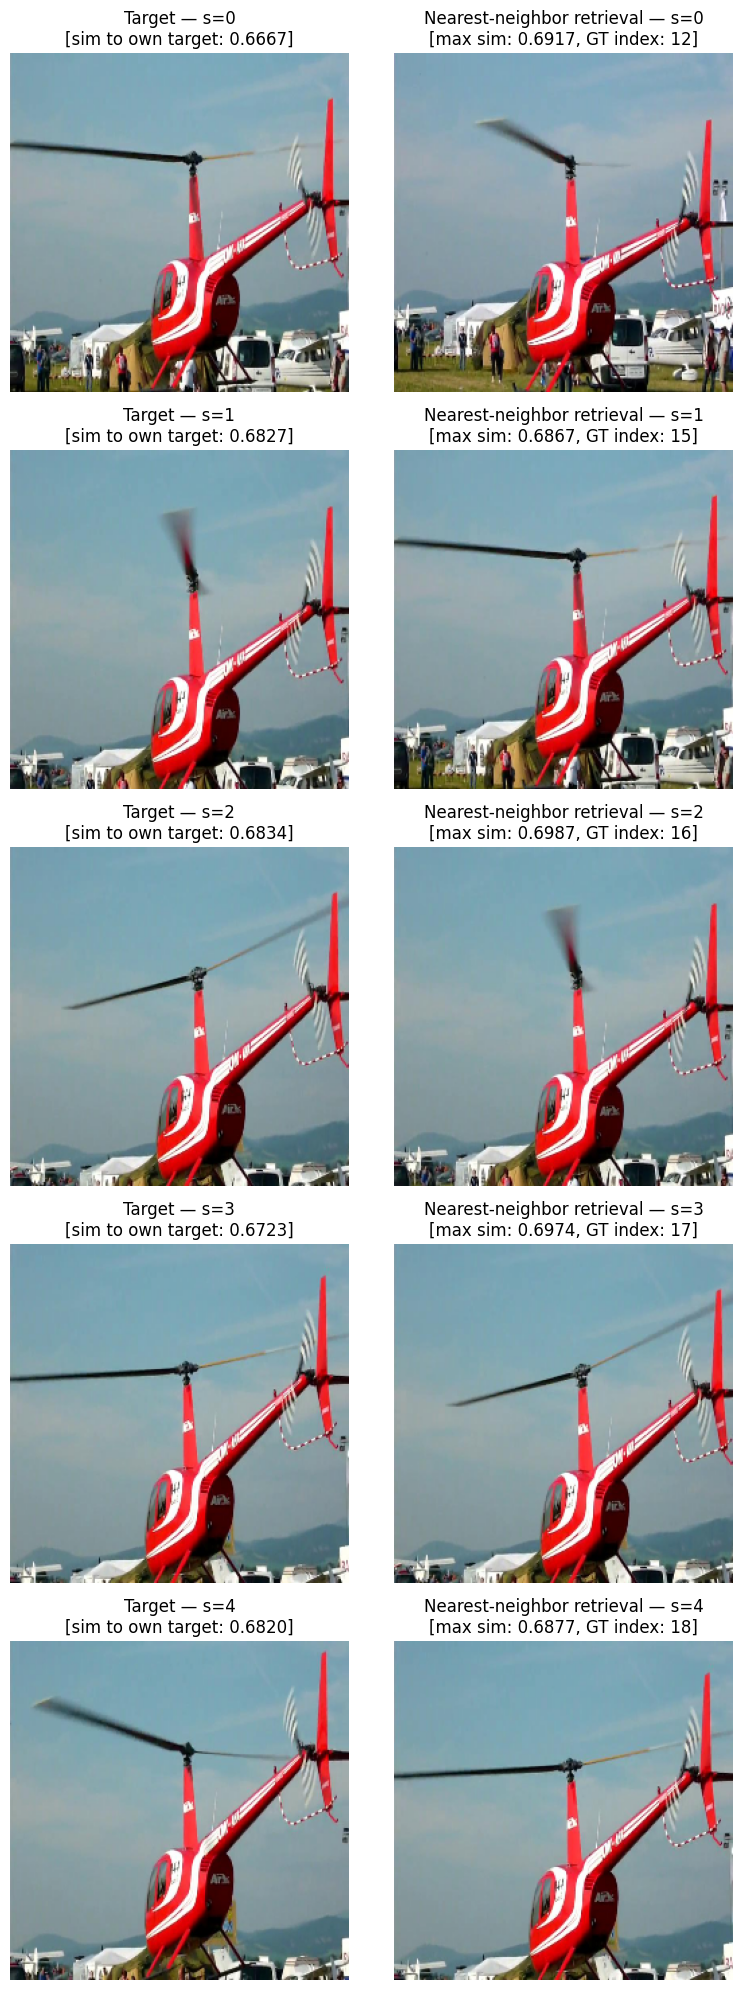

In [35]:
def plot_target_pred(targets, all_frames, gt_features, pred_features, C):
    """all_frames: (B, C+S, 3, H, W) raw pixel frames in the SAME order as
    gt_features (context frames, then target frames). C is the number of
    context frames, needed to locate each target's own index in gt_features."""

    gt_features = F.normalize(gt_features, dim=-1)
    pred_features = F.normalize(pred_features, dim=-1)

    # cosine similarity: (B, S, C+S)
    sim = torch.einsum("bsd,btd->bst", pred_features, gt_features)
    max_sim, max_idx = sim.max(dim=-1)

    S = targets.shape[1]
    fig, axes = plt.subplots(S, 2, figsize=(8, 4 * S))
    if S == 1:
        axes = axes[None, :]

    def to_img(t):
        arr = t.detach().cpu().permute(1, 2, 0).numpy()
        return (arr * 255.0).clip(0, 255).astype("uint8")   # frames are [0,1] floats -- scale before uint8 cast

    for s in range(S):
        target_img = to_img(targets[0, s])

        nn_idx = int(max_idx[0, s].item())
        pred_img = to_img(all_frames[0, nn_idx])

        true_idx = C + s                        # this target's own position in gt_features
        true_sim = sim[0, s, true_idx].item()    # similarity of the prediction to its OWN true target

        axes[s, 0].imshow(target_img)
        axes[s, 0].set_title(f"Target — s={s}\n[sim to own target: {true_sim:.4f}]")
        axes[s, 0].axis("off")

        axes[s, 1].imshow(pred_img)
        axes[s, 1].set_title(
            f"Nearest-neighbor retrieval — s={s}\n"
            f"[max sim: {max_sim[0, s].item():.4f}, GT index: {nn_idx}]"
        )
        axes[s, 1].axis("off")

    plt.tight_layout()
    plt.show()


C = context.shape[1]
all_frames = torch.cat((context, targets), dim=1)     # (B, C+S, 3, H, W), same order as representations
representations = torch.cat((context_feat, target_feat), dim=1)

plot_target_pred(targets, all_frames, representations, preds, C)
